### Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm


In [2]:
df = pd.read_csv("medicaid-provider-spending.csv")
print(df.columns.tolist())  # column names

C:\Users\David\AppData\Local\Temp\ipykernel_27968\2520810276.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("medicaid-provider-spending.csv")


['BILLING_PROVIDER_NPI_NUM', 'SERVICING_PROVIDER_NPI_NUM', 'HCPCS_CODE', 'CLAIM_FROM_MONTH', 'TOTAL_UNIQUE_BENEFICIARIES', 'TOTAL_CLAIMS', 'TOTAL_PAID']


### filter on codes provided by Clinicans

In [3]:
codes_df = pd.read_excel("Codes Manual.xlsx")

codes = (
    codes_df["CODE"]
    .astype(str)
    .str.strip()
    .dropna()
    .unique()
)

df["HCPCS_CODE"] = df["HCPCS_CODE"].astype(str).str.strip()

filtered_df = df[df["HCPCS_CODE"].isin(codes)].copy()

In [4]:
filtered_df["CLAIM_FROM_MONTH"] = pd.to_datetime(filtered_df["CLAIM_FROM_MONTH"])

filtered_df.sample(20)

,BILLING_PROVIDER_NPI_NUM,SERVICING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS,TOTAL_PAID
138977533,1477541183,1578506507,85025,2024-05-01,34,39,316.99
143008609,1134126659,1720099344,85025,2024-07-01,59,76,278.96
117251441,1316994734,1316994734,86140,2024-02-01,49,60,566.21
200895362,1346332954,1023235041,85025,2024-06-01,13,14,0.00
204491834,1043269798,1194798900,85025,2019-06-01,14,17,0.00
125294238,1356309553,1164471884,93306,2023-10-01,16,16,465.29
116771816,1215914288,1215914288,82570,2023-11-01,200,218,572.60
138775635,1992753222,1992753222,86140,2024-02-01,58,66,319.11
167225189,1518042175,1821250291,85025,2022-06-01,14,20,104.61
188649115,1780633289,1255336814,85025,2018-11-01,40,51,8.00


### Check join status

In [5]:
codes_set = set(codes_df["CODE"].astype(str).str.strip())
claims_set = set(filtered_df["HCPCS_CODE"].astype(str).str.strip())

missing_codes = codes_set - claims_set

print("total codes: {}".format(len(codes_set)))
print("missing codes: {}".format(len(missing_codes)))


total codes: 139
missing codes: 42


In [6]:
missing_codes_df = (
    pd.DataFrame({"HCPCS_CODE": list(missing_codes)})
    .assign(HCPCS_CODE=lambda d: d["HCPCS_CODE"].astype(str).str.strip())
    .merge(
        codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip()),
        left_on="HCPCS_CODE",
        right_on="CODE",
        how="left"
    )
    .drop(columns=["CODE"])
)

missing_codes_df

,HCPCS_CODE,Description
0,85304,Protein C / S
1,0465T,Sudomotor testing via electrochemical skin con...
2,85255,Clotting factors (selective use)
3,85243,Clotting factors (selective use)
4,85248,Clotting factors (selective use)
5,71253,CT Chest
6,85256,Clotting factors (selective use)
7,85253,Clotting factors (selective use)
8,86791,Viral serologies (lab dependent)
9,71258,CT Chest


### Join

In [7]:
filtered_df["HCPCS_CODE"] = filtered_df["HCPCS_CODE"].astype(str).str.strip()
codes_df["CODE"] = codes_df["CODE"].astype(str).str.strip()

retsef_meta = codes_df[["CODE", "Description"]].drop_duplicates()

filtered_with_meta = filtered_df.merge(
    retsef_meta,
    left_on="HCPCS_CODE",
    right_on="CODE",
    how="left"
).drop(columns=["CODE"])

monthly = (
    filtered_with_meta
    .groupby(["HCPCS_CODE", "CLAIM_FROM_MONTH"], as_index=False)
    .agg({
        "Description": "first",
        "TOTAL_PAID": "sum",
        "TOTAL_CLAIMS": "sum",
        "TOTAL_UNIQUE_BENEFICIARIES": "sum"
    })
    .sort_values(["HCPCS_CODE", "CLAIM_FROM_MONTH"])
)

monthly

,HCPCS_CODE,CLAIM_FROM_MONTH,Description,TOTAL_PAID,TOTAL_CLAIMS,TOTAL_UNIQUE_BENEFICIARIES
0,0295T,2018-03-01,Extended cardiac monitoring,50.58,14,14
1,0295T,2018-04-01,Extended cardiac monitoring,388.26,15,14
2,0295T,2018-05-01,Extended cardiac monitoring,0.00,14,14
3,0295T,2018-06-01,Extended cardiac monitoring,610.95,36,26
4,0295T,2018-08-01,Extended cardiac monitoring,0.00,33,32
...,...,...,...,...,...,...
7215,96133,2024-08-01,Neuropsychological testing (sometimes used dep...,920573.73,3660,3031
7216,96133,2024-09-01,Neuropsychological testing (sometimes used dep...,1064361.81,4105,3255
7217,96133,2024-10-01,Neuropsychological testing (sometimes used dep...,1185552.50,4511,3358
7218,96133,2024-11-01,Neuropsychological testing (sometimes used dep...,655603.90,2288,1710


### Pivot

In [21]:
claims_pivot = (
    monthly
    .pivot(index="CLAIM_FROM_MONTH", columns="HCPCS_CODE", values="TOTAL_CLAIMS")
    .sort_index()
)

claims_pivot

HCPCS_CODE,0295T,0296T,0297T,0298T,0464T,11104,11105,27447,71250,71260,...,95910,95911,95912,95913,95921,95922,95923,95992,96132,96133
CLAIM_FROM_MONTH,,,,,,,,,,,,,,,,,,,,,
2018-01-01,NaN,45.0,566.0,88.0,NaN,NaN,NaN,48.0,27478.0,43766.0,...,1988.0,3631.0,2052.0,1968.0,1983.0,219.0,5089.0,103.0,NaN,NaN
2018-02-01,NaN,108.0,705.0,192.0,NaN,NaN,NaN,78.0,23265.0,36996.0,...,1908.0,3012.0,2138.0,1704.0,2201.0,162.0,5225.0,77.0,NaN,NaN
2018-03-01,14.0,112.0,908.0,276.0,NaN,NaN,NaN,127.0,27596.0,42410.0,...,2148.0,3440.0,2613.0,2240.0,2277.0,196.0,5457.0,94.0,NaN,NaN
2018-04-01,15.0,106.0,889.0,191.0,NaN,NaN,NaN,52.0,25878.0,40153.0,...,1977.0,3404.0,2089.0,2111.0,2048.0,207.0,4766.0,64.0,NaN,NaN
2018-05-01,14.0,188.0,1048.0,183.0,NaN,NaN,NaN,48.0,27656.0,43631.0,...,2091.0,4045.0,2338.0,2173.0,2074.0,239.0,4633.0,120.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,NaN,NaN,NaN,NaN,NaN,1034.0,51.0,330.0,39813.0,51760.0,...,2028.0,4937.0,2161.0,2372.0,2485.0,189.0,3385.0,135.0,8554.0,3660.0
2024-09-01,NaN,NaN,NaN,NaN,NaN,853.0,63.0,277.0,36924.0,46116.0,...,1680.0,4047.0,2215.0,2089.0,1810.0,168.0,2623.0,164.0,8939.0,4105.0
2024-10-01,NaN,NaN,NaN,NaN,NaN,1070.0,76.0,400.0,40455.0,46950.0,...,1966.0,4871.0,2432.0,2231.0,2127.0,158.0,3168.0,180.0,9617.0,4511.0


### Cutoff last 6 months due to reporting errors

In [22]:
full_months = pd.date_range(
    monthly["CLAIM_FROM_MONTH"].min(),
    monthly["CLAIM_FROM_MONTH"].max(),
    freq="MS"
)
claims_pivot = claims_pivot.reindex(full_months)
claims_pivot.index.name = "CLAIM_FROM_MONTH"
claims_pivot

HCPCS_CODE,0295T,0296T,0297T,0298T,0464T,11104,11105,27447,71250,71260,...,95910,95911,95912,95913,95921,95922,95923,95992,96132,96133
CLAIM_FROM_MONTH,,,,,,,,,,,,,,,,,,,,,
2018-01-01,NaN,45.0,566.0,88.0,NaN,NaN,NaN,48.0,27478.0,43766.0,...,1988.0,3631.0,2052.0,1968.0,1983.0,219.0,5089.0,103.0,NaN,NaN
2018-02-01,NaN,108.0,705.0,192.0,NaN,NaN,NaN,78.0,23265.0,36996.0,...,1908.0,3012.0,2138.0,1704.0,2201.0,162.0,5225.0,77.0,NaN,NaN
2018-03-01,14.0,112.0,908.0,276.0,NaN,NaN,NaN,127.0,27596.0,42410.0,...,2148.0,3440.0,2613.0,2240.0,2277.0,196.0,5457.0,94.0,NaN,NaN
2018-04-01,15.0,106.0,889.0,191.0,NaN,NaN,NaN,52.0,25878.0,40153.0,...,1977.0,3404.0,2089.0,2111.0,2048.0,207.0,4766.0,64.0,NaN,NaN
2018-05-01,14.0,188.0,1048.0,183.0,NaN,NaN,NaN,48.0,27656.0,43631.0,...,2091.0,4045.0,2338.0,2173.0,2074.0,239.0,4633.0,120.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,NaN,NaN,NaN,NaN,NaN,1034.0,51.0,330.0,39813.0,51760.0,...,2028.0,4937.0,2161.0,2372.0,2485.0,189.0,3385.0,135.0,8554.0,3660.0
2024-09-01,NaN,NaN,NaN,NaN,NaN,853.0,63.0,277.0,36924.0,46116.0,...,1680.0,4047.0,2215.0,2089.0,1810.0,168.0,2623.0,164.0,8939.0,4105.0
2024-10-01,NaN,NaN,NaN,NaN,NaN,1070.0,76.0,400.0,40455.0,46950.0,...,1966.0,4871.0,2432.0,2231.0,2127.0,158.0,3168.0,180.0,9617.0,4511.0


In [23]:
cutoff = full_months.max() - pd.DateOffset(months=6)

claims_pivot = claims_pivot.loc[claims_pivot.index <= cutoff]

claims_pivot

HCPCS_CODE,0295T,0296T,0297T,0298T,0464T,11104,11105,27447,71250,71260,...,95910,95911,95912,95913,95921,95922,95923,95992,96132,96133
CLAIM_FROM_MONTH,,,,,,,,,,,,,,,,,,,,,
2018-01-01,NaN,45.0,566.0,88.0,NaN,NaN,NaN,48.0,27478.0,43766.0,...,1988.0,3631.0,2052.0,1968.0,1983.0,219.0,5089.0,103.0,NaN,NaN
2018-02-01,NaN,108.0,705.0,192.0,NaN,NaN,NaN,78.0,23265.0,36996.0,...,1908.0,3012.0,2138.0,1704.0,2201.0,162.0,5225.0,77.0,NaN,NaN
2018-03-01,14.0,112.0,908.0,276.0,NaN,NaN,NaN,127.0,27596.0,42410.0,...,2148.0,3440.0,2613.0,2240.0,2277.0,196.0,5457.0,94.0,NaN,NaN
2018-04-01,15.0,106.0,889.0,191.0,NaN,NaN,NaN,52.0,25878.0,40153.0,...,1977.0,3404.0,2089.0,2111.0,2048.0,207.0,4766.0,64.0,NaN,NaN
2018-05-01,14.0,188.0,1048.0,183.0,NaN,NaN,NaN,48.0,27656.0,43631.0,...,2091.0,4045.0,2338.0,2173.0,2074.0,239.0,4633.0,120.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-02-01,NaN,NaN,NaN,NaN,NaN,1222.0,125.0,340.0,44720.0,53953.0,...,2226.0,5392.0,2533.0,2601.0,2784.0,87.0,3499.0,211.0,8561.0,4493.0
2024-03-01,NaN,NaN,NaN,NaN,NaN,1105.0,90.0,333.0,46829.0,55503.0,...,2163.0,5386.0,2421.0,2762.0,2870.0,116.0,3699.0,142.0,8992.0,4238.0
2024-04-01,NaN,NaN,NaN,NaN,NaN,1122.0,70.0,457.0,46576.0,54998.0,...,2194.0,5880.0,2762.0,2966.0,2776.0,181.0,3647.0,178.0,9451.0,4221.0


In [ ]:
claims_pivot.to_csv("claims_pivot.csv")

### ITS

$Y_tâ€‹=B_0â€‹+B_1â€‹T+B_2â€‹X_tâ€‹+B_3â€‹(X_tâ€‹â‹…T)$

In [12]:
code = "93303"
intervention_month = pd.Timestamp("2021-01-01")

ts = claims_pivot[[code]].reset_index()
ts.columns = ["month", "y"]

# start at first non-zero month so leading missing months are excluded
nonzero_idx = ts.index[ts["y"].fillna(0) > 0]
if len(nonzero_idx) > 0:
    ts = ts.loc[nonzero_idx[0]:].reset_index(drop=True)

ts["y"] = ts["y"].fillna(0)

# time trend
ts["T"] = np.arange(len(ts))

# intervention dummy
ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

# time since intervention
ts["T'"] = 0
if (ts["month"] >= intervention_month).any():
    intervention_idx = ts.loc[ts["month"] >= intervention_month, "T"].min()
    ts.loc[ts["month"] >= intervention_month, "T'"] = (
        ts.loc[ts["month"] >= intervention_month, "T"] - intervention_idx + 1
    )

ts.head(50)

,month,y,T,X_t,T'
0,2018-01-01,25388.0,0,0,0
1,2018-02-01,22642.0,1,0,0
2,2018-03-01,26041.0,2,0,0
3,2018-04-01,24698.0,3,0,0
4,2018-05-01,26248.0,4,0,0
5,2018-06-01,23165.0,5,0,0
6,2018-07-01,24290.0,6,0,0
7,2018-08-01,27872.0,7,0,0
8,2018-09-01,22649.0,8,0,0
9,2018-10-01,27717.0,9,0,0


In [13]:
X = sm.add_constant(ts[["T", "X_t", "T'"]])
y = ts["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     58.63
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           1.63e-19
Time:                        12:15:26   Log-Likelihood:                -750.32
No. Observations:                  78   AIC:                             1509.
Df Residuals:                      74   BIC:                             1518.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.43e+04   1221.172     19.901      0.0

In [14]:
X

,const,T,X_t,T'
0,1.0,0,0,0
1,1.0,1,0,0
2,1.0,2,0,0
3,1.0,3,0,0
4,1.0,4,0,0
...,...,...,...,...
73,1.0,73,1,38
74,1.0,74,1,39
75,1.0,75,1,40
76,1.0,76,1,41


In [15]:
def _trim_to_first_nonzero(ts):
    ts = ts.copy()
    ts["month"] = pd.to_datetime(ts["month"])
    ts["y"] = pd.to_numeric(ts["y"], errors="coerce")

    nonzero_idx = ts.index[ts["y"].fillna(0) > 0]
    if len(nonzero_idx) == 0:
        return ts.iloc[0:0].copy()

    start_idx = nonzero_idx[0]
    return ts.loc[start_idx:].reset_index(drop=True)


def fit_its_single(ts, intervention_month):
    ts = _trim_to_first_nonzero(ts)
    if ts.empty:
        raise ValueError("Series has no non-zero observations after trimming leading months.")

    # outcome
    ts["y"] = ts["y"].fillna(0)

    # time
    ts["T"] = np.arange(len(ts))

    # intervention indicator
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

    # post time
    ts["post_time"] = 0
    if (ts["month"] >= intervention_month).any():
        intervention_idx = ts.loc[ts["month"] >= intervention_month, "T"].min()
        ts.loc[ts["month"] >= intervention_month, "post_time"] = (
            ts.loc[ts["month"] >= intervention_month, "T"] - intervention_idx + 1
        )

    # design matrix
    X = sm.add_constant(ts[["T", "X_t", "post_time"]])
    y = ts["y"]

    # fit model
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    return model

In [16]:
results = []

intervention_month = pd.Timestamp("2021-01-01")

# Build metadata lookup once
meta_lookup = (
    codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
    .drop_duplicates(subset=["CODE"])
    .set_index("CODE")[["Description"]]
    .to_dict(orient="index")
)

for code in claims_pivot.columns:

    # build time series
    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)

    # skip sparse series
    observed = int(ts["y"].notna().sum())
    if observed < 37:
        print(f"Skipping code {code} due to insufficient data (observed {observed} months)")
        continue

    # get metadata
    code_str = str(code).strip()
    meta = meta_lookup.get(code_str, {})
    desc = meta.get("Description")

    try:
        model = fit_its_single(ts, intervention_month)

        params = model.params
        pvals = model.pvalues
        conf = model.conf_int()

        results.append({
            "HCPCS_CODE": code_str,
            "Description": desc,

            "B0_const": params.get("const", np.nan),
            "B1_time": params.get("T", np.nan),
            "B2_level": params.get("X_t", np.nan),
            "B3_slope": params.get("post_time", np.nan),

            "p_const": pvals.get("const", np.nan),
            "p_time": pvals.get("T", np.nan),
            "p_level": pvals.get("X_t", np.nan),
            "p_slope": pvals.get("post_time", np.nan),

            "ci_const_low": conf.loc["const", 0] if "const" in conf.index else np.nan,
            "ci_const_high": conf.loc["const", 1] if "const" in conf.index else np.nan,

            "ci_time_low": conf.loc["T", 0] if "T" in conf.index else np.nan,
            "ci_time_high": conf.loc["T", 1] if "T" in conf.index else np.nan,

            "ci_level_low": conf.loc["X_t", 0] if "X_t" in conf.index else np.nan,
            "ci_level_high": conf.loc["X_t", 1] if "X_t" in conf.index else np.nan,

            "ci_slope_low": conf.loc["post_time", 0] if "post_time" in conf.index else np.nan,
            "ci_slope_high": conf.loc["post_time", 1] if "post_time" in conf.index else np.nan,

            "R_squared": model.rsquared,
            "N_obs": observed
        })

    except Exception as e:
        results.append({
            "HCPCS_CODE": code_str,
            "Description": desc,
            "ERROR": str(e)
        })


Skipping code 0295T due to insufficient data (observed 29 months)
Skipping code 0296T due to insufficient data (observed 36 months)
Skipping code 0297T due to insufficient data (observed 36 months)
Skipping code 0298T due to insufficient data (observed 36 months)
Skipping code 0464T due to insufficient data (observed 2 months)
Skipping code 75557 due to insufficient data (observed 31 months)
Skipping code 75563 due to insufficient data (observed 4 months)
Skipping code 84150 due to insufficient data (observed 16 months)
Skipping code 93245 due to insufficient data (observed 34 months)


In [17]:
results_df = pd.DataFrame(results)

# optional sorting
results_df = results_df.sort_values("p_level")

def smart_format(x):
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        if x == 0:
            return "0.0000"
        if abs(x) < 1e-4:
            return f"{x:.2E}"
        return f"{x:.4f}"
    return x

for col in results_df.columns:
    if pd.api.types.is_numeric_dtype(results_df[col]):
        results_df[col] = results_df[col].apply(smart_format)

#replace nan with 0
results_df = results_df.replace("nan", 0)
results_df = results_df.replace("", 0)
results_df

,HCPCS_CODE,Description,B0_const,B1_time,B2_level,B3_slope,p_const,p_time,p_level,p_slope,ci_const_low,ci_const_high,ci_time_low,ci_time_high,ci_level_low,ci_level_high,ci_slope_low,ci_slope_high,R_squared,N_obs
64,93247,continuous cardiac monitoring and detection,-9.41E-12,4.28E-13,2650.2276,78.3128,0,0,3.41E-88,1.47E-30,0,0,0,0,2389.3208,2911.1345,64.9550,91.6705,0.9773,42
61,93243,continuous cardiac monitoring and detection,-8.13E-12,3.74E-13,2175.9547,98.4905,1.0000,1.0000,5.65E-58,7.12E-45,-2.77E-05,2.77E-05,-1.56E-06,1.56E-06,1910.2480,2441.6614,84.7566,112.2243,0.9752,42
63,93246,continuous cardiac monitoring and detection,-1.85E-12,8.81E-14,430.5377,40.5841,1.0000,1.0000,1.19E-12,1.94E-37,-1.59E-05,1.59E-05,-1.06E-06,1.06E-06,311.8045,549.2710,34.3634,46.8047,0.9543,42
65,93248,continuous cardiac monitoring and detection,-1.94E-12,9.24E-14,442.6388,45.7355,1.0000,1.0000,1.15E-08,8.81E-38,-9.64E-06,9.64E-06,-6.93E-07,6.93E-07,290.6330,594.6446,38.7586,52.7124,0.9438,42
30,85390,Coagulation interpretation/report,644.0450,43.5308,1272.0892,-48.8628,5.72E-08,2.09E-06,1.53E-08,5.64E-07,411.4599,876.6302,25.5478,61.5137,831.4525,1712.7258,-68.0045,-29.7211,0.9139,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21,85250,Clotting factors (selective use),62.2027,1.7218,9.3398,2.5786,7.36E-37,9.37E-06,0.5382,5.35E-05,52.5902,71.8153,0.9602,2.4833,-20.3962,39.0757,1.3275,3.8297,0.8062,78
23,85270,Clotting factors (selective use),40.0766,2.5099,-6.5297,-1.3023,5.70E-14,3.99E-14,0.5393,0.0047,29.6241,50.5291,1.8593,3.1605,-27.3796,14.3202,-2.2059,-0.3988,0.6811,78
83,95922,"Vasomotor adrenergic function (e.g., BP respon...",104.4009,13.8485,-34.1049,-25.6013,0.0063,2.77E-14,0.5693,1.67E-26,29.5161,179.2857,10.2812,17.4158,-151.5634,83.3536,-30.3110,-20.8916,0.6341,78
71,94762,"Pulse oximetry (spot / overnight, sometimes us...",4259.3363,-40.0319,110.9260,43.4560,8.40E-54,0.0132,0.7991,0.0157,3718.7617,4799.9110,-71.6840,-8.3798,-743.1420,964.9939,8.2087,78.7032,0.2324,78


In [18]:
results_df.to_csv("its_results.csv", index=False)

### Plots

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     77.07
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           1.03e-22
Time:                        12:15:27   Log-Likelihood:                -444.78
No. Observations:                  78   AIC:                             897.6
Df Residuals:                      74   BIC:                             907.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         54.1742     24.298      2.230      0.0

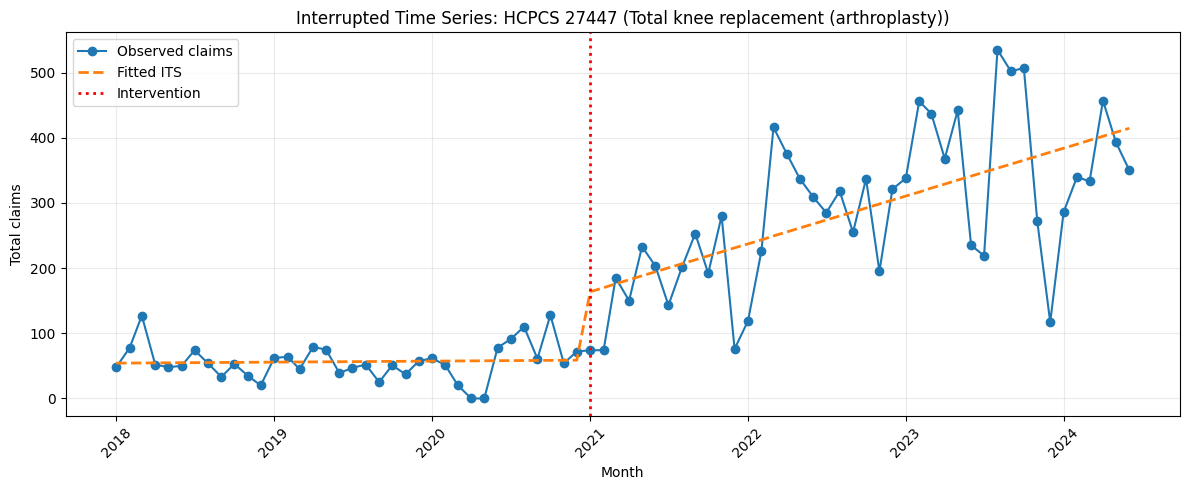

In [19]:
def plot_interrupted_time_series(claims_pivot, code, intervention_month, fill_missing=0, figsize=(12, 5)):
    code = str(code).strip()

    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)
    if ts.empty:
        raise ValueError(f"Series {code} has no non-zero observations after trimming leading months.")
    ts["y"] = ts["y"].fillna(fill_missing)

    # time trend
    ts["T"] = np.arange(len(ts))

    # intervention dummy
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

    # time since intervention
    ts["T'"] = 0
    if (ts["month"] >= intervention_month).any():
        intervention_idx = ts.loc[ts["month"] >= intervention_month, "T"].min()
        ts.loc[ts["month"] >= intervention_month, "T'"] = (
            ts.loc[ts["month"] >= intervention_month, "T"] - intervention_idx + 1
        )

    X = sm.add_constant(ts[["T", "X_t", "T'"]])
    y = ts["y"]

    model = sm.OLS(y, X).fit()
    ts["y_hat"] = model.predict(X)

    desc = None
    if "codes_df" in globals() and {"CODE", "Description"}.issubset(codes_df.columns):
        meta = codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
        match = meta.loc[meta["CODE"] == code, "Description"]
        if not match.empty:
            desc = match.iloc[0]

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(ts["month"], ts["y"], marker="o", linewidth=1.5, label="Observed claims")
    ax.plot(ts["month"], ts["y_hat"], linestyle="--", linewidth=2, label="Fitted ITS")
    ax.axvline(intervention_month, color="red", linestyle=":", linewidth=2, label="Intervention")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total claims")

    title = f"Interrupted Time Series: HCPCS {code}"
    if desc:
        title = f"{title} ({desc})"
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.xticks(rotation=45)
    plt.tight_layout()

    return ts, model, fig, ax


# Example
ts, model, fig, ax = plot_interrupted_time_series(
    claims_pivot=claims_pivot,
    code="27447",
    intervention_month=pd.Timestamp("2021-01-01")
)

print(model.summary())